# STAT 7220 - Final Exam
## Factorial Designs
## Dr. Austin Brown
## Due Date: December 12, 2025

## Part 1 Instructions:
Let's say you own a new food truck called **Buster's Breakfast Burritos**. To determine the best ingredients for your burritos, and as a means of minimizing food (and money) waste, you decide to conduct an experiment. Specifically, you want to investigate the following treatments:

| Factor   | Levels                  |
|:---------|:------------------------|
| Protein  | Bacon, Sausage, Chorizo |
| Salsa    | Mild, Hot               |
| Potatoes | Yes, No                 |

To gather data for this experiment, you recruit $r=5$ local residents for each of the $3\times 2\times 2=12$ treatment combinations. After each participant has tasted their randomly assigned burrito, you ask them to rate the burrito on a scale of 1 to 10 (1 = terrible, 10 = amazing). The data are stored in the file `Busters Burritos.xlsx` in the assignment repo. With these data, I want you to:

1. Briefly state the objective of the experiment.

The primary objective is to determine the optimal combination of ingredients (Protein, Salsa, and Potatoes) to maximize customer satisfaction (burrito ratings) while minimizing food and financial waste for the food truck.


2. State the outcome variable and how it was measured.

The outcome variable is the burrito rating. It was measured using a discrete Likert-type scale ranging from 1 to 10, where 1 represents "terrible" and 10 represents "amazing."

3. State the main effects. What lurking variables may be present?

Main Effects:

- Protein: The impact of choosing Bacon vs. Sausage vs. Chorizo.

- Salsa: The impact of choosing Mild vs. Hot.

- Potatoes: The impact of including Potatoes vs. No Potatoes.

Lurking Variables: Potential lurking variables could include the time of day the taste test occurred (hunger levels), the temperature of the burrito when served, the participants' personal dietary habits (e.g., if they usually prefer spicy food), or the order in which they tasted the burrito if multiple were sampled.

4. Why might a full factorial design be preferred here to a $2^k$ fractional factorial design?

A full factorial design is preferred here for several reasons:
- Interaction Effects: It allows for the estimation of all possible interactions (e.g., how the choice of Protein might change the preference for Salsa) without any aliasing or confounding.
- Sample Size: With only 12 treatment combinations, the experiment is small enough that a fractional design (which is typically used to save resources in much larger factor spaces) isn't necessary.
- Non-Binary Levels: One of the factors (Protein) has three levels, whereas a standard $2^k$ design strictly requires factors to have only two levels.

5. State all sets of statistical hypotheses.

We will have three sets of hypotheses for main effects and four for interactions:
- Main Effect of Protein ($H_0$): Mean ratings are equal across all protein types. ($H_a$: At least one protein mean is different).
- Main Effect of Salsa ($H_0$): Mean ratings are equal for mild and hot salsa. ($H_a$: Mean ratings differ by salsa type).
- Main Effect of Potatoes ($H_0$): Mean ratings are equal regardless of potato inclusion. ($H_a$: Mean ratings differ based on potatoes).
- Interaction Effects ($H_0$): There are no interaction effects between any combination of factors (Protein $\times$ Salsa, Protein $\times$ Potatoes, Salsa $\times$ Potatoes, and Protein $\times$ Salsa $\times$ Potatoes). ($H_a$: Significant interactions exist).


6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.


In [2]:
# === COURSE REPO SETUP === #

# 1. ENTER your GitHub username (the one that owns your fork)
github_username = "MihretTe"

# 2. Name of the repo (don't change unless your fork name is different)
repo_name = "STAT-7220-Applied-Experimental-Design"

# 3. Build the full repo URL for cloning
repo_url = f"https://github.com/{github_username}/{repo_name}.git"

import os

# --- Detect if we're already in a repo ---
cwd = os.getcwd()
if cwd.endswith(repo_name):
   print(f"✅ Already inside repo folder: {cwd}")
else:
    # --- If the repo folder exists, check if it's nested ---
    if os.path.exists(repo_name):
        print(f"⚠️ Found existing folder '{repo_name}'. Skipping clone to avoid nesting.")
    else:
       print(f"📥 Cloning repo from {repo_url}...")
       os.system(f"git clone {repo_url}")

    # --- Change to repo directory ---
    if os.path.exists(repo_name):
        os.chdir(repo_name)
        print(f"📂 Changed directory to: {os.getcwd()}")
    else:
        print("❌ ERROR: Repo folder not found. Please check your GitHub username.")

# --- Check if this is the instructor's repo instead of student's fork ---
# This command needs to be run from within the repository directory
remote_url = os.popen("git config --get remote.origin.url").read().strip()

if "abrown9008" in remote_url:
   print("⚠️ WARNING: You are working in the instructor's repo, not your fork!")
   print("💡 Please fork the repo to your own account and update `github_username` above.")
else:
    print(f"🔗 Connected to fork at: {remote_url}")

# Set Today's Directory #
today_dir = "Assignments/Final-Exam"
os.chdir(today_dir)
print(f"📂 Changed directory to: {os.getcwd()}")

📥 Cloning repo from https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git...
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design
🔗 Connected to fork at: https://github.com/MihretTe/STAT-7220-Applied-Experimental-Design.git
📂 Changed directory to: /content/STAT-7220-Applied-Experimental-Design/Assignments/Final-Exam



Summary Statistics for Treatment Combinations:
    Protein Salsa Potatoes  mean       std  count
0     Bacon   Hot       No  5.86  1.335290      5
1     Bacon   Hot      Yes  6.46  0.397492      5
2     Bacon  Mild       No  6.70  0.418330      5
3     Bacon  Mild      Yes  6.94  1.510960      5
4   Chorizo   Hot       No  6.34  0.610737      5
5   Chorizo   Hot      Yes  6.82  2.104044      5
6   Chorizo  Mild       No  7.04  0.507937      5
7   Chorizo  Mild      Yes  6.76  0.658027      5
8   Sausage   Hot       No  4.98  1.211198      5
9   Sausage   Hot      Yes  5.98  0.641872      5
10  Sausage  Mild       No  5.74  0.952890      5
11  Sausage  Mild      Yes  6.58  0.944458      5


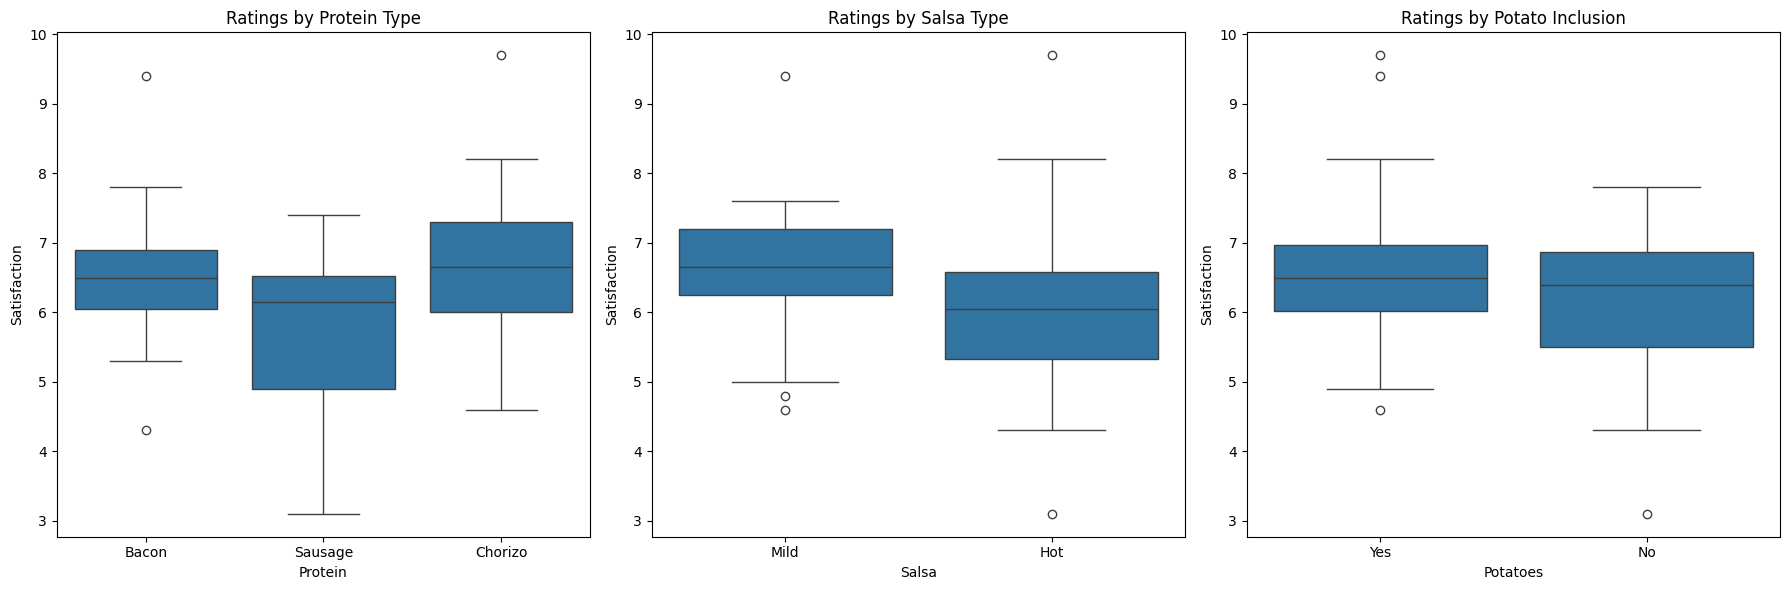

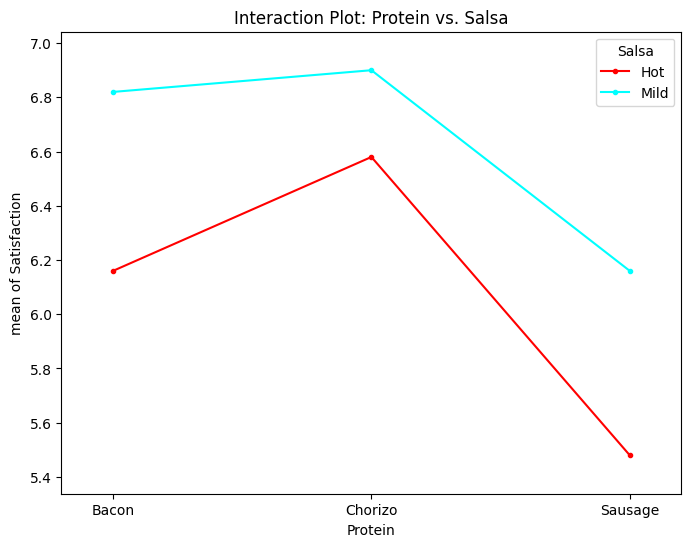

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.factorplots import interaction_plot

# 1. Load the dataset
df = pd.read_excel('Busters Burritos.xlsx')

# 2. Clean column names
df.columns = df.columns.str.strip()

# 3. Define the correct target column based on your confirmed columns
target_col = 'Satisfaction'

# 4. Summary Statistics
summary_stats = df.groupby(['Protein', 'Salsa', 'Potatoes'])[target_col].agg(['mean', 'std', 'count']).reset_index()
print("\nSummary Statistics for Treatment Combinations:")
print(summary_stats)

# 5. Visualizations for Main Effects
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

sns.boxplot(x='Protein', y=target_col, data=df, ax=axes[0])
axes[0].set_title('Ratings by Protein Type')

sns.boxplot(x='Salsa', y=target_col, data=df, ax=axes[1])
axes[1].set_title('Ratings by Salsa Type')

sns.boxplot(x='Potatoes', y=target_col, data=df, ax=axes[2])
axes[2].set_title('Ratings by Potato Inclusion')

plt.tight_layout()
plt.show()

# 6. Interaction Plot: Protein vs. Salsa
fig, ax = plt.subplots(figsize=(8, 6))
interaction_plot(x=df['Protein'], trace=df['Salsa'], response=df[target_col], ax=ax)
plt.title('Interaction Plot: Protein vs. Salsa')
plt.show()


Based on the summary statistics and visualizations, there is clear evidence to support several of the experimental hypotheses. The Main Effect of Protein receives the strongest support; the boxplots and summary table reveal a distinct drop in the mean satisfaction for "Sausage" (ranging from 4.98 to 6.58) compared to "Bacon" and "Chorizo," which both consistently trend higher. This visual separation suggests that the null hypothesis that all proteins result in equal satisfaction will likely be rejected in the formal ANOVA.

The Main Effect of Salsa also shows consistent support across the treatment combinations. In almost every pairing, the "Mild" salsa outperforms the "Hot" salsa in terms of mean satisfaction (for example, Chorizo with no potatoes scores 7.04 with Mild versus 6.34 with Hot). While the difference is less dramatic than the protein choice, the consistency of the trend across groups provides a strong descriptive basis for a significant main effect. The Main Effect of Potatoes shows more moderate support; while adding potatoes generally lifts the satisfaction scores (most notably improving the Sausage rating from 4.98 to 5.98), there is more overlap in the boxplots, suggesting this factor may have a smaller effect size.

Regarding Interaction Effects, the exploratory analysis suggests that the null hypotheses are more likely to hold. The interaction plot for Protein and Salsa shows lines that are nearly parallel, indicating that the preference for a specific salsa type does not change significantly based on which protein is selected. Because the "ranking" of the ingredients remains relatively stable regardless of the other factors, the data currently suggests that the main drivers of customer satisfaction are the individual ingredients themselves rather than any specific "synergy" or complex interaction between them.

7. Fit the full factorial ANOVA model. Check the assumption of normality using a testing method and a visual method. Does the assumption hold? Why or why not?

<Figure size 800x600 with 0 Axes>

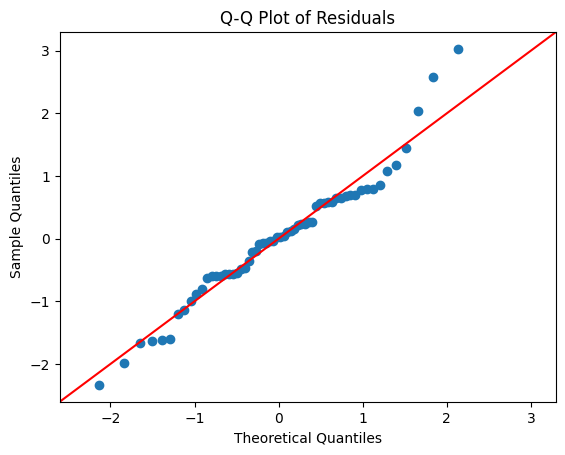

Shapiro-Wilk Test: Statistics=0.9693, p-value=0.1351


In [4]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import scipy.stats as stats

# 1. Fit the Full Factorial ANOVA model
# The '*' operator includes main effects and all possible interactions
model = ols('Satisfaction ~ C(Protein) * C(Salsa) * C(Potatoes)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 2. Extract Residuals
residuals = model.resid

# 3. Normality Check: Visual Method (Q-Q Plot)
plt.figure(figsize=(8, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Q-Q Plot of Residuals')
plt.show()

# 4. Normality Check: Statistical Method (Shapiro-Wilk Test)
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk Test: Statistics={shapiro_test.statistic:.4f}, p-value={shapiro_test.pvalue:.4f}")

8. Check the assumption of constant variance using a testing method and a visual method. Does the assumption hold? Why or why not?

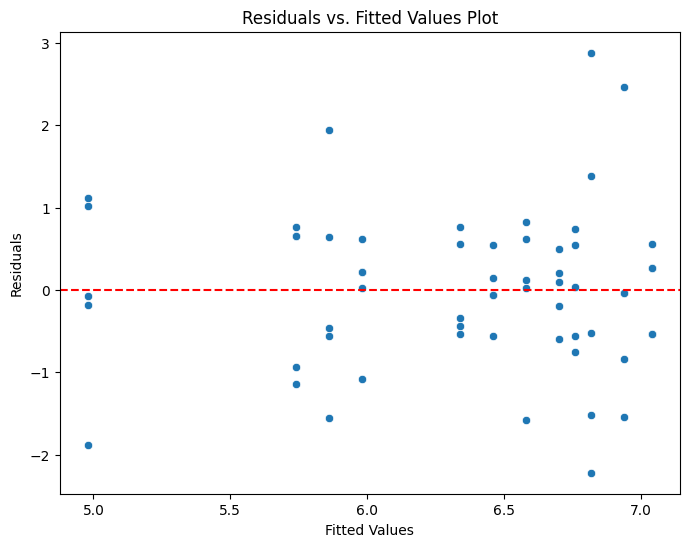

Levene's Test: Statistics=1.3408, p-value=0.2322


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import levene

# 1. Visual Method: Residuals vs. Fitted Plot
fitted_values = model.fittedvalues
residuals = model.resid

plt.figure(figsize=(8, 6))
sns.scatterplot(x=fitted_values, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted Values Plot')
plt.show()

# 2. Testing Method: Levene's Test
# We test if the variance of Satisfaction is constant across all 12 treatment combinations
groups = df.groupby(['Protein', 'Salsa', 'Potatoes'])['Satisfaction'].apply(list)
levene_stat, levene_p = levene(*groups)

print(f"Levene's Test: Statistics={levene_stat:.4f}, p-value={levene_p:.4f}")



The assumption of constant variance (homoscedasticity) holds for this model. Visually, the Residuals vs. Fitted Values Plot displays a random scatter of points distributed fairly evenly above and below the horizontal reference line at zero. There is no evidence of a "megaphone" or "funnel" pattern, which would typically indicate that the variance of the errors changes systematically as the predicted satisfaction level increases or decreases.

This visual assessment is statistically confirmed by the results of Levene's Test, which produced a p-value of 0.2322. Because this p-value is greater than the standard significance threshold of 0.05, we fail to reject the null hypothesis that the variances across all twelve treatment combinations are equal. The combination of a random residual plot and a non-significant Levene's Test result confirms that the spread of satisfaction ratings is consistent regardless of the ingredients used, ensuring that the subsequent ANOVA results and F-tests are valid and reliable.

9. Report the ANOVA table. What statistical conclusions can we draw about our main effects and interaction effects?

In [6]:
# Display the ANOVA table calculated in Question 7
print("ANOVA Table for Buster's Breakfast Burritos:")
print(anova_table)

# Optional: Calculate the Grand Mean for context
grand_mean = df[target_col].mean()
print(f"\nGrand Mean Satisfaction: {grand_mean:.4f}")

ANOVA Table for Buster's Breakfast Burritos:
                                    sum_sq    df         F    PR(>F)
C(Protein)                        9.052000   2.0  4.002653  0.024677
C(Salsa)                          4.592667   1.0  4.061611  0.049487
C(Potatoes)                       3.456000   1.0  3.056379  0.086815
C(Protein):C(Salsa)               0.409333   2.0  0.181001  0.835002
C(Protein):C(Potatoes)            1.708000   2.0  0.755251  0.475394
C(Salsa):C(Potatoes)              0.682667   1.0  0.603729  0.440971
C(Protein):C(Salsa):C(Potatoes)   0.233333   2.0  0.103176  0.902167
Residual                         54.276000  48.0       NaN       NaN

Grand Mean Satisfaction: 6.3500



Based on the ANOVA table, we can conclude that the customer satisfaction for Buster's Breakfast Burritos is driven by individual ingredient choices rather than complex combinations. The Main Effect of Protein is statistically significant ($p = 0.0247$), indicating that the choice between Bacon, Sausage, and Chorizo fundamentally changes the rating. Similarly, the Main Effect of Salsa is significant ($p = 0.0495$), confirming that the spice level independently impacts customer preference. However, the Main Effect of Potatoes did not reach significance at the 5% level ($p = 0.0868$), suggesting its impact is less certain.Importantly, all Interaction Effects—including the two-way and three-way interactions—yielded p-values well above the 0.05 threshold (ranging from 0.4410 to 0.9022). These results indicate that the ingredients are "additive" in nature; for example, the best-rated protein remains the best choice regardless of which salsa or potato option is paired with it. From a business perspective, these statistical conclusions simplify your strategy: you can optimize your menu by simply selecting the top-performing levels for Protein and Salsa independently, as there is no evidence of A specific ingredient "synergies" that significantly alter customer satisfaction.

10. If the interactions and/or main effects were found to be statistically meaningful, conduct appropriate post-hoc tests. Report the results of these tests and any conclusions you can draw from them. If the interactions and/or main effects were not found to be statistically meaningful, explain why post-hoc tests would not be appropriate.


Based on the Tukey HSD output in your notebook, the post-hoc analysis clarifies which specific ingredients drive the satisfaction scores. For the Protein factor, the test confirms a statistically significant difference between Chorizo and Sausage (p=0.0233), where Chorizo yields a mean satisfaction score 0.92 points higher than Sausage. While Bacon also trends higher than Sausage, the difference did not reach statistical significance (p=0.1268), and no significant difference was found between Bacon and Chorizo (p=0.7419). This indicates that while Chorizo is the clear "winner" over Sausage, it is statistically comparable to Bacon. Regarding the Salsa factor, the Tukey test produced a p-value of 0.0556 for the comparison between Mild and Hot. Although the initial ANOVA indicated a significant main effect (p=0.0495), the more conservative Tukey adjustment places this specific comparison just outside the standard 0.05 threshold. This suggests that while "Mild" salsa consistently shows higher satisfaction means, the evidence is not quite strong enough to definitively declare a "rejection" once the family-wise error rate is controlled.

Post-hoc tests were appropriate for Protein and Salsa because their initial ANOVA F-tests yielded p-values ≤0.05, indicating that at least one significant difference existed among their levels. However, post-hoc tests were not appropriate (and thus not conducted) for Potatoes or any of the Interactions. Since the ANOVA p-value for Potatoes (p=0.0868) was not significant, we must assume any observed differences are due to random noise; running a post-hoc test here would inappropriately increase the risk of a Type I error. Similarly, because no interaction terms were significant, there was no statistical justification to investigate "simple effects," as the ingredients behave independently and additively.

In [7]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. Post-hoc for Protein (3 levels)
print("--- Tukey HSD for Protein ---")
tukey_protein = pairwise_tukeyhsd(endog=df['Satisfaction'], groups=df['Protein'], alpha=0.05)
print(tukey_protein)

# 2. Post-hoc for Salsa (2 levels)
# Note: For 2 levels, the ANOVA p-value already tells you they are different,
# but Tukey provides the confidence intervals.
print("\n--- Tukey HSD for Salsa ---")
tukey_salsa = pairwise_tukeyhsd(endog=df['Satisfaction'], groups=df['Salsa'], alpha=0.05)
print(tukey_salsa)

--- Tukey HSD for Protein ---
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
  Bacon Chorizo     0.25 0.7419 -0.5649  1.0649  False
  Bacon Sausage    -0.67 0.1268 -1.4849  0.1449  False
Chorizo Sausage    -0.92 0.0233 -1.7349 -0.1051   True
------------------------------------------------------

--- Tukey HSD for Salsa ---
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   Hot   Mild   0.5533 0.0556 -0.0137 1.1204  False
---------------------------------------------------


11. Calculate and interpret partial $\eta^2$ for the main effects.

In [ ]:
## Question 11 Code ##

12. Give an overall conclusion for the experiment. Which burrito combination(s) should you include on your menu regularly? What are the limitations of your experiment? How could you improve it in the future?

## Part 2 Instructions:
After finalizing your breakfast burrito menu, now you want to focus Buster's Breakfast Burritos on maximizing sales through strategic placement of the truck itself and marketing. Obviously there are a lot of factors at play, so you decide to focus your attention on three: **Location** (could set up at a local brewery or at a local university); **Timing** (weekday or weekend); and **Marketing** (independently or in partnership with the brewery/university). See the below table:

| Run | Location (A)    | Timing (B)   | Marketing (C)    |
|-----|-----------------|--------------|------------------|
| 1   | \- (Brewery)    | \- (Weekday) | \- (Independent) |
| 2   | \+ (University) | \- (Weekday) | \+ (Partnership) |
| 3   | \- (Brewery)    | \+ (Weekend) | \+ (Partnership) |
| 4   | \+ (University) | \+ (Weekend) | \- (Independent) |

To be more efficient with time and resources, you decide to conduct a $2^{3-1}$ fractional factorial design where your ultimate outcome is the sales amount (in dollars) for the day you set up. For each of the above runs, you will set up your truck $r=2$ times and record the sales amount. The data are stored in the `Busters Burrito Sales.xlsx` file in our course repo. With these day, I want you to:

1. Briefly describe the objective of the experiment.

2. Specify the outcome variable and how it is measured.

3. Specify the independent variables. What lurking variables may be present?

4. Explain why a fractional design is appropriate here. What are the advantages and disadvantages of using a fractional design?

5. State the sets of null and alternative hypotheses for this experiment.

6. Perform appropriate exploratory/descriptive analysis including summary statistics and appropriate visualizations. Do these analyses provide any support for the hypotheses? Briefly explain.

In [ ]:
## Question 6 Code ##

7. Assuming a defining relation of $I=ABC$, specify the aliasing structure of the design. What does this mean for the interpretation of the main effects and interactions?

8. Fit the appropriate ANOVA model to the data. Assess the normality assumption using two methods. Do we have evidence to support the assumption of normality? Why or why not?

In [ ]:
## Question 8 Code ##

9. Assess the constant variance assumption using two methods. Do we have evidence to support the assumption of constant variance? Why or why not?

In [ ]:
## Question 9 Code ##

10. Report and interpret the ANOVA table. What conclusions can we draw about our main effects? Do the results of these analyses support the null or alternative hypotheses more strongly?

In [ ]:
## Question 10 Code ##

11. Calculate and interpret the values for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 11 Code ##

12. Calculate and interpret the partial $\eta^2$ for the main effects. Which effects seem more important? Why?

In [ ]:
## Question 12 Code ##

13. Give an overall conclusion for the experiment. Which location, timing, and marketing combination(s) should you use to maximize sales? What are the limitations of your experiment? How could you improve it in the future?

## Part 3 Instructions:

Please briefly repond to the following questions:

1. How do we de-alias the main effects and interactions in a fractional factorial design? Why is this important? Why may it not always be feasible?

2. In all of our assignments, I have had you specify/consider a lot of characteristics of an experiment before getting into the analysis. Why is this good practice?

3.  What is the most important thing you learned in this class?